<a href="https://colab.research.google.com/github/BernardoBib/Conversao-Eletromecanica-Python/blob/main/Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalar pacotes necessarios
!pip install scipy matplotlib numpy sympy

# Importações
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.interpolate import interp1d, CubicSpline
from scipy.optimize import fsolve

plt.style.use('seaborn-v0_8-darkgrid')

In [ ]:
# 1. constantes

# Constantes Físicas
u0 = 4 * np.pi * 1e-7      # Permeabilidade do vácuo (H/m)
g = 9.81                   # Aceleração da gravidade (m/s^2)

# Constantes Geométricas
g0 = 1e-3                  # Entreferro inicial (m)
W = 0.04                   # Comprimento W (m)
D = 0.035                  # Espessura D (m)
d = 0.008                  # Comprimento do ímã (m)
A = W * D                  # Área da seção transversal (m²)

# Bobina
N1 = 1000                  # Número de espiras

# Curva B x H (dados) + Ímã
B_data = np.array([0, 0.6, 0.8, 1.0, 1.08, 1.2])                # Tesla
H_data = np.array([-51.2, -48.0, -45.4, -38.2, -32.8, 0]) * 1e3 # A/m

Br = 1.2                  # Indução residual (T)
Hc = -50e3                # Campo coercivo (A/m)
uIma = Br / (-Hc)         # Permeabilidade do ímã (modelo linear)
Nf_If = -Hc * d           # FMM equivalente do ímã

# Interpolação da curva real
interp_H_por_B = interp1d(B_data, H_data, kind='cubic', fill_value="extrapolate")

# Vetor de posições (usado nas funções e na execução)
x_posicoes = np.linspace(1e-5, 0.02, 100)

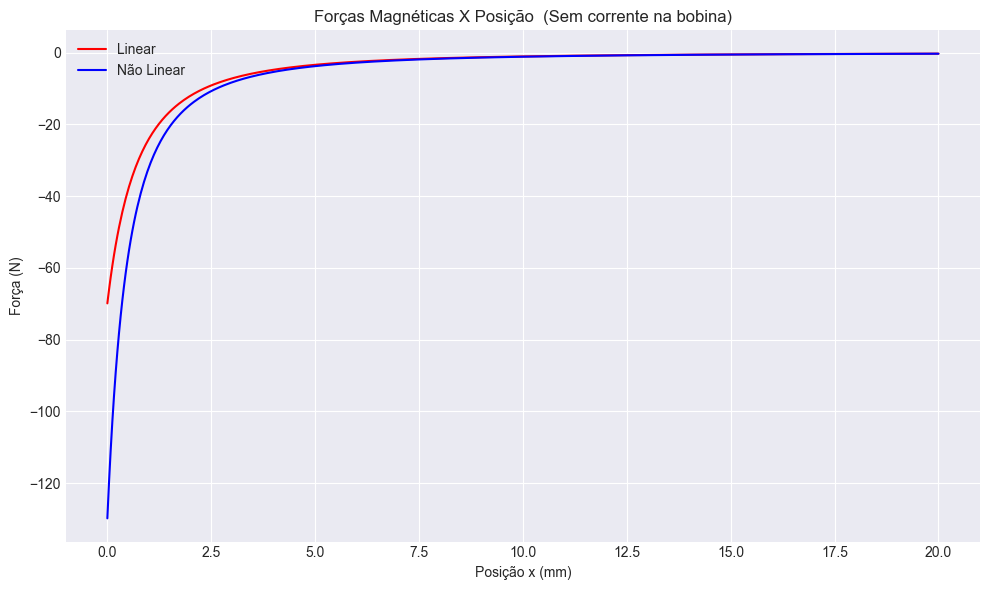

In [ ]:
# determinação da força magnética pela posição do elemento

# Método 1: Linear

# Modela o sistema assumindo comportamento linear do material magnético (μ constante),
# representando o circuito por relutâncias equivalentes (entreferro variável, ímã e entreferro fixo).
# A relutância total é invertida para obter a permeância equivalente e, a partir da energia
# magnética armazenada W = (FMM² / 2) * (1/R_tot), a força é calculada pela derivada
# da energia em relação à posição, resultando em F = (FMM² / 2) * d(1/R_tot)/dx.

x_sym = sp.Symbol('x', real=True, positive=True)
R_x = x_sym / (u0 * W * D); R_fic = d / (uIma * W * D); R_g0 = g0 / (u0 * W * D)
R_tot = R_x + R_fic + R_g0
inv_Rtot = 1 / R_tot
inv_Rtot_dx = sp.diff(inv_Rtot, x_sym)
F_expr = (Nf_If**2 / 2) * inv_Rtot_dx
F_func_linear = sp.lambdify(x_sym, F_expr, modules='numpy')
x_posicoes = np.linspace(0, 0.02, 500)
F_vals_linear = F_func_linear(x_posicoes)


# Método 2: Não Linear - Numérico

# Para cada posição, determina numericamente o ponto de operação magnético
# resolvendo a equação de equilíbrio entre a curva B-H real do material e a
# reta de carga do circuito; com o valor de Bm obtido, calcula a força pela
# expressão da pressão magnética F = (B² A) / (2 μ0).
F_vals_nonlinear = np.zeros_like(x_posicoes)

for i, x_pos in enumerate(x_posicoes):

    # Equação do ponto de operação: H_material(B) = H_reta_de_carga(B, x)
    def equacao_ponto_operacao(Bm):
        Hm_curva = interp_H_por_B(Bm)
        Hm_reta_carga = - (Bm / (u0 * d)) * (g0 + x_pos)
        return Hm_curva - Hm_reta_carga

    Bm_operacao = fsolve(equacao_ponto_operacao, x0=1.0)[0]

    F_vals_nonlinear[i] = -(Bm_operacao**2 * A) / (2 * u0)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x_posicoes * 1000, F_vals_linear, label='Linear', color='red')
ax.plot(x_posicoes * 1000, F_vals_nonlinear, label='Não Linear', color='blue')

ax.set_xlabel('Posição x (mm)')
ax.set_ylabel('Força (N)')
ax.set_title('Forças Magnéticas X Posição  (Sem corrente na bobina)')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

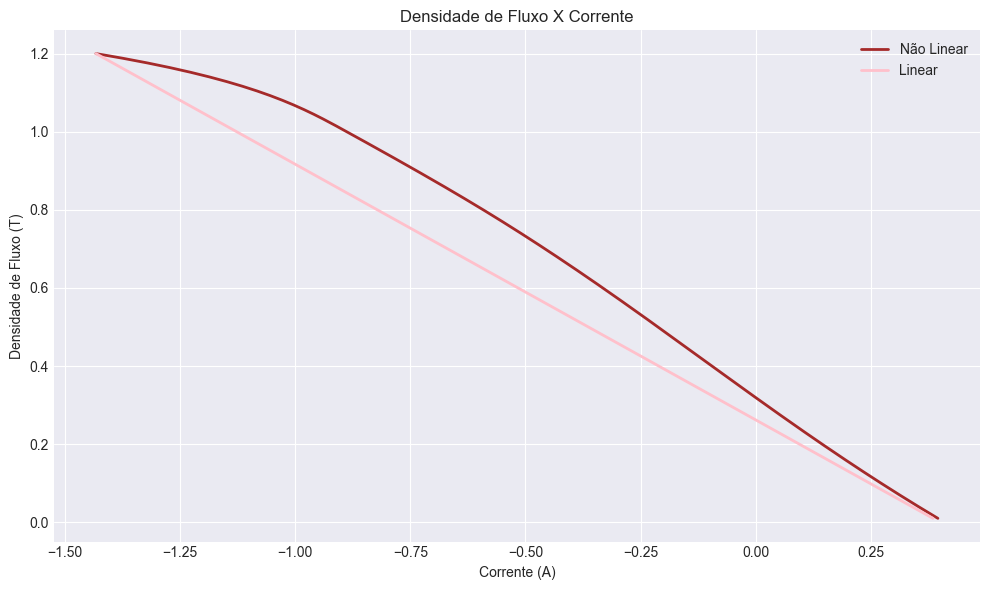

In [ ]:
# Analisa a relação entre densidade de fluxo magnético Bm e corrente I1

# impondo a equação do circuito magnético para uma posição fixa do entreferro Bm vs I1
# Bm vs I1
Bm = np.linspace(0.01, 1.2, 200) # Gera valores de Bm evitando zero para impedir divergência na curva B-H

# Calcula a corrente no modelo não linear usando a curva B-H real do material
I1 = -((interp_H_por_B(Bm))*d + (Bm/u0)*(g0+0.5e-3)) / N1

# Calcula a corrente no modelo linear assumindo permeabilidade constante do ímã
Hm_linear = (Bm / uIma) + Hc
I1_Linear = -(Hm_linear * d + (Bm / u0) * (g0 + 0.5e-3)) / N1

#plota gráfico

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(I1, Bm, label='Não Linear', color='brown', linewidth=2)
ax.plot(I1_Linear, Bm, label='Linear', color='pink', linewidth=2)

ax.set_title('Densidade de Fluxo X Corrente')
ax.set_xlabel('Corrente (A)')
ax.set_ylabel('Densidade de Fluxo (T)')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

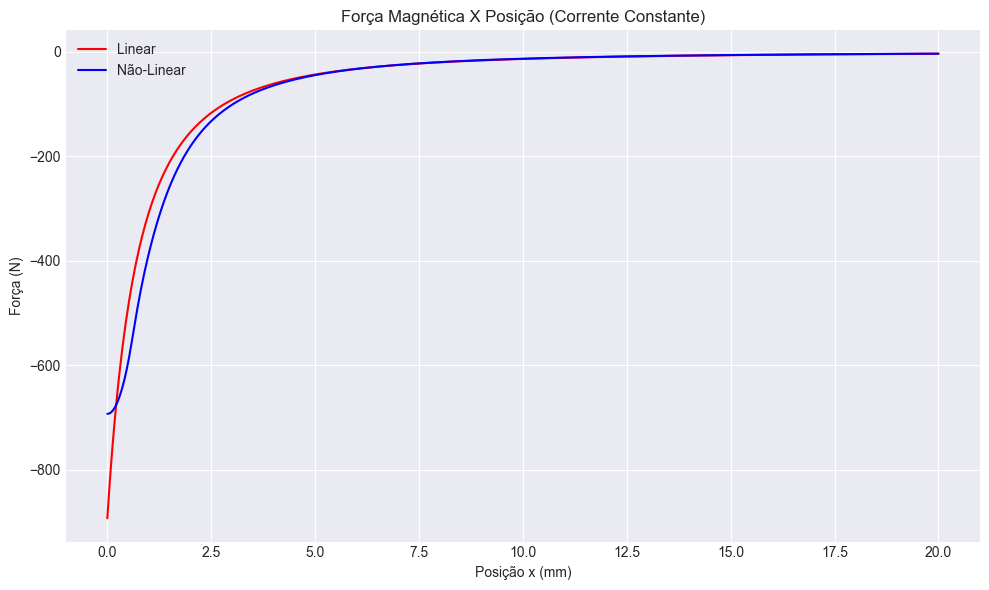

In [ ]:
# Força magnética em função da posição

# Calcula a força magnética assumindo comportamento linear do circuito magnético,
# modelando o sistema por relutâncias equivalentes e obtendo a força pela derivada
# da energia magnética armazenada em relação à posição (F = dW/dx)
def calc_forca_linear(x_posicoes, FMM_total):
    x_sym = sp.Symbol('x', real=True, positive=True)
    R_x = x_sym / (u0 * A)
    R_fic = d / (uIma * A)
    R_g0 = g0 / (u0 * A)
    R_tot = R_x + R_fic + R_g0

    F_expr = (FMM_total**2 / 2) * sp.diff(1/R_tot, x_sym)
    F_func = sp.lambdify(x_sym, F_expr, modules='numpy')
    return F_func(x_posicoes)


# Calcula a força magnética considerando a não linearidade do material,
# determinando o ponto de operação na curva B-H via solução numérica,
# integrando a coenergia magnética em função da corrente e obtendo a força
# como a derivada espacial da coenergia (F = dW'c/dx)
def calc_forca_nao_linear(x_posicoes, I_final):

    def calculate_lambda(i, x_pos):
        FMM_coil = N1 * i
        def equation(Bm):
            Hm_curva = interp_H_por_B(Bm)
            Hm_load_line = (FMM_coil - (Bm / u0) * (g0 + x_pos)) / d
            return Hm_curva - Hm_load_line
        Bm_sol, = fsolve(equation, x0=[0.8])
        return N1 * Bm_sol * A

    Wc_vals = np.zeros_like(x_posicoes)
    for i, x_pos in enumerate(x_posicoes):
        integrand = lambda current: calculate_lambda(current, x_pos)
        Wc_vals[i], _ = integrate.quad(integrand, 0, I_final, limit=50)

    return np.gradient(Wc_vals, x_posicoes)




# Determina a corrente constante impondo um ponto de operação (B,H) no circuito magnético,
# aplicando a lei das quedas de força magnetomotriz (FMM) no ímã e no entreferro e,
# em seguida, dividindo a FMM total pelo número de espiras para obter a corrente da bobina
B_op_normal = 1.07
H_op_normal = -31e3
x_fixo = 0.5e-3
FMM_circuito = H_op_normal * d + (B_op_normal / u0) * (g0 + x_fixo)
I1_constante = FMM_circuito / N1


# Calcula a força magnética no modelo linear somando a FMM do campo fixo com a da bobina
# e utilizando essa FMM total como entrada para a expressão analítica baseada em relutância
FMM_total_linear = Nf_If + N1 * I1_constante

F_linear = calc_forca_linear(x_posicoes, FMM_total_linear)

# Calcula a força pelo modelo não linear.
F_nonlinear = calc_forca_nao_linear(x_posicoes, I1_constante)



# Plota o gráfico comparativo da força magnética em função da posição.
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_posicoes * 1000, F_linear, label='Linear', color='red')
ax.plot(x_posicoes * 1000, F_nonlinear, label='Não-Linear', color='blue')
ax.set_xlabel('Posição x (mm)')
ax.set_ylabel('Força (N)')
ax.set_title('Força Magnética X Posição (Corrente Constante)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

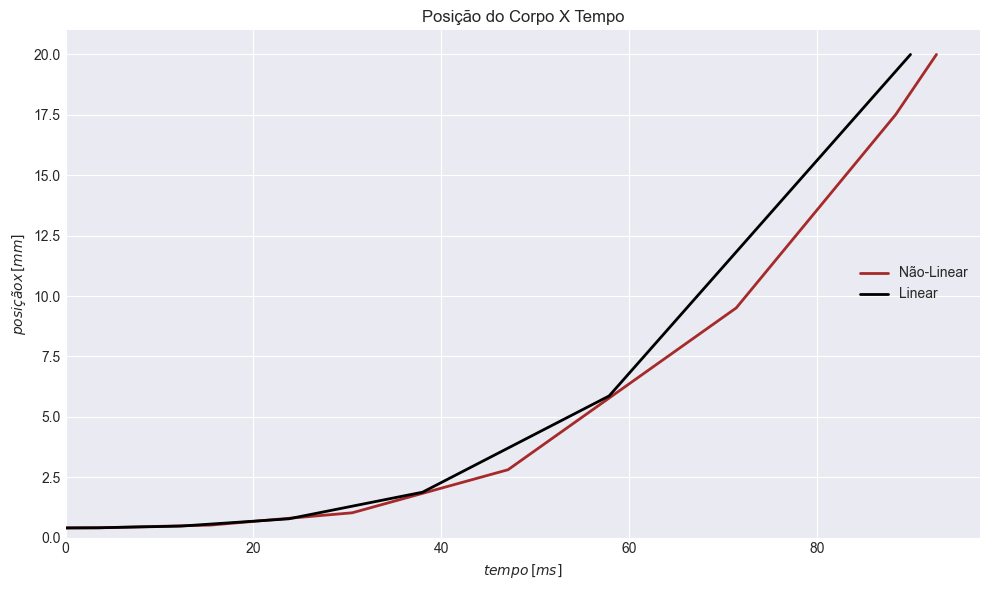

In [ ]:
# Posição do corpo em função do tempo

x_inicial_sim = 0.4e-3

plt.style.use('seaborn-v0_8-darkgrid')


# Simula a dinâmica do corpo resolvendo numericamente a equação diferencial do movimento
# (segunda lei de Newton), onde a força magnética depende da posição; a força é interpolada
# para permitir avaliação contínua durante a integração temporal e o sistema é resolvido
# como uma EDO de segunda ordem convertida em sistema de primeira ordem
def simular_movimento(forca_vs_pos_vals, x_vals_sim, x_inicial):

    forca_interp_func = interp1d(x_vals_sim, forca_vs_pos_vals, kind='cubic', fill_value="extrapolate")

    forca_inicial = forca_interp_func(x_inicial)
    massa_corpo = 1.10 * abs(forca_inicial) / g

    def modelo_dinamico(t, y):
        posicao, velocidade = y
        forca_mag = forca_interp_func(posicao)
        forca_resultante = massa_corpo * g + forca_mag
        aceleracao = forca_resultante / massa_corpo
        return [velocidade, aceleracao]

    y0 = [x_inicial, 0.0]
    t_span = [0, 0.1]

    def fim_do_entreferro(t, y): return y[0] - x_vals_sim[-1]
    fim_do_entreferro.terminal = True
    fim_do_entreferro.direction = 1

    return integrate.solve_ivp(modelo_dinamico, t_span, y0, events=fim_do_entreferro, dense_output=True)


pos_linear = simular_movimento(F_linear, x_posicoes, x_inicial_sim)
pos_nonlinear = simular_movimento(F_nonlinear, x_posicoes, x_inicial_sim)

fig, ax = plt.subplots(figsize=(10, 6))

# Modelo Não-Linear

# O if garante que:
# 1) O solver realmente convergiu (pos_nonlinear.success == True)
# 2) Existem pelo menos dois pontos calculados
#    (não é possível traçar uma curva com apenas um ponto)
if pos_nonlinear.success and len(pos_nonlinear.t) > 1:
    ax.plot(pos_nonlinear.t * 1000,
            pos_nonlinear.y[0] * 1000,
            label='Não-Linear',
            color='brown',
            linewidth=2)

# Modelo Linear
if pos_linear.success and len(pos_linear.t) > 1:
    ax.plot(pos_linear.t * 1000,
            pos_linear.y[0] * 1000,
            label='Linear',
            color='black',
            linewidth=2)

# Melhorando a visualização
ax.set_xlabel(r'$tempo\,[ms]$')
ax.set_ylabel(r'$posição x\,[mm]$')
ax.set_title('Posição do Corpo X Tempo')
ax.grid(True, which='both')
ax.legend(loc='center right')
ax.set_ylim(0, x_posicoes[-1] * 1000 + 1)
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()